In [1]:
from random import random

import numpy as np
import os
import torch
import utils
from utils import *
from unet import ImCondModel, UNetModel_imcond_wrapper
from topodataset import TopoDataSet
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
weight_path = 'model_weights/otcfm_topo_weights_step_145000.pt'

In [3]:
# load the data:
# DATASETS/DATALOADER
bs=4
num_workers=4
downsampling_factor=1
limit_num_data=np.inf
crop_size=300
use_cfg=True
use_ddc=False
threshold_input=True


dataset = TopoDataSet(
    dir='data/',
    downsampling_factor=downsampling_factor,
    limit_num_data=limit_num_data,
    crop_size=crop_size,
    threshold_input=threshold_input,
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 682/682 [00:00<?, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 696/696 [00:00<00:00, 232682.57it/s]
0it [00:00, ?it/s]
100%|██████████| 843/843 [00:00<00:00, 267681.00it/s]
0it [00:00, ?it/s]
100%|██████████| 712/712 [00:00<00:00, 237426.02it/s]
0it [00:00, ?it/s]
100%|██████████| 856/856 [00:00<00:00, 428286.32it/s]
0it [00:00, ?it/s]
100%|██████████| 635/635 [00:00<00:00, 142009.23it/s]
0it [00:00, ?it/s]
100%|██████████| 534/534 [00:00<00:00, 131734.99it/s]
0it [00:00, ?it/s]
100%|██████████| 427/427 [00:00<00:00, 190305.79it/s]
0it [00:00, ?it/s]
100%|██████████| 613/613 [00:00<00:00, 306814.84it/s]
0it [00:00, ?it/s]
100%|██████████| 608/608 [00:00<00:00, 522569.02it/s]
0it [00:00, ?it/s]
100%|██████████| 699/699 [00:00<00:00, 348859.89it/s]
0it [00:00, ?it/s]
100%|██████████| 717/717 [00:00<00:00, 857518.10it/s]
0it [00:00, ?it/s]
100%|██████████| 656/656 [00:00<?, ?it/s]

dataset contains 8678 images


In [4]:
# get images from training set:
all_imgs = []
all_bgs = []
for i, (img, bg) in tqdm(enumerate(dataloader), total=len(dataloader)):
    all_imgs.append(img)
    all_bgs.append(bg)
    if i >= 100:
        break


  5%|▍         | 100/2169 [00:16<05:34,  6.19it/s]


In [5]:
all_imgs = torch.cat(all_imgs, dim=0)
all_bgs = torch.cat(all_bgs, dim=0)
all_imgs *= 0.5
all_imgs += 0.5

In [6]:
print(all_imgs.shape)

torch.Size([404, 3, 300, 300])


In [7]:


# Load the model
h = w = 300
num_channel = 32
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

inject_imcond = True

if not inject_imcond:
    model = ImCondModel(
        dim=(3, h, w),  # note: in local test run we had this worng (dim was at (..., 32, 32). which effectively means we were applying attention after only one time downsampling (att. resolutions was 16)
        num_res_blocks=2,
        num_channels=num_channel,
        channel_mult=[1, 1, 2, 2, 2],
        num_heads=4,
        num_head_channels=-1,
        attention_ds=(2**5,),
        dropout=0.1,
    ).to(
        device
    )  # new dropout + bs of 128
else:
    num_im_cond_channels = 1
    if use_cfg:
        num_im_cond_channels  += 1
    if use_ddc:
        num_im_cond_channels += 3  # 3 as the cell staining images have 3 channels
    model = UNetModel_imcond_wrapper(
        dim=(3, h, w),
        num_res_blocks=2,
        num_channels=num_channel,
        channel_mult=[1, 1, 2, 2, 2],
        num_heads=4,
        num_head_channels=-1,
        attention_ds=(2**5,),
        dropout=0.1,
        num_cond_im_channels=num_im_cond_channels,
    ).to(device)
    


cuda
using model with image conditioning injection in unet!


D:\topochip-flow-matching\Topochip-flow-matching\venv\Lib\site-packages\torch\nn\init.py:453: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [8]:
checkpoint = torch.load(weight_path, map_location=device)

C:\Users\s161975\AppData\Local\Temp\ipykernel_5020\2211059199.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_location=device)


In [9]:
device

'cuda'

In [10]:
key = 'ema_model'  # or 'net_model'
# key = 'net_model'
model.load_state_dict(checkpoint[key])

<All keys matched successfully>

In [11]:
model.to(device)

UNetModel_imcond_wrapper(
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_blocks): ModuleList(
    (0): TimestepEmbedSequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1-2): 2 x TimestepEmbedSequential(
      (0): ResBlock(
        (in_layers): Sequential(
          (0): GroupNorm32(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (h_upd): Identity()
        (x_upd): Identity()
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=32, bias=True)
        )
        (imcond_emb_layers): Sequential(
          (0): SiLU()
          (1): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (out_layers): Sequential(
          (

In [13]:
# generate k qualtitative images of real and fake data:

k = 20
bs = 4

imgs_gen = []
imgs_real = []
for i in tqdm(range(np.ceil(k/bs).astype(int))):
    random_idx = np.random.randint(all_bgs.shape[0], size=bs)
    x1 = all_imgs[random_idx].to(device)
    bg = all_bgs[random_idx].to(device)
    some_bgs = utils.prepare_cfg_conditioning(bg, 0) if use_cfg else bg
    imgs_this_gen = generate_samples_topo(model, False, None, 0, 'test', some_bgs[:, None, ...], num_int_steps=100,
                                          use_cfg=True, cfg_strength=1, x1=x1)
    imgs_gen.append(imgs_this_gen.cpu())
    img_and_bg_real = torch.cat([all_bgs[random_idx], all_imgs[random_idx]], dim=1)
    imgs_real.append(img_and_bg_real.cpu())

imgs_gen = torch.cat(imgs_gen, dim=0)
imgs_real = torch.cat(imgs_real, dim=0)



  0%|          | 0/5 [00:00<?, ?it/s]

Your vector field does not have `nn.Parameters` to optimize.


 20%|██        | 1/5 [00:47<03:10, 47.52s/it]

Your vector field does not have `nn.Parameters` to optimize.


 40%|████      | 2/5 [01:34<02:21, 47.31s/it]

...

 60%|██████    | 3/5 [02:26<01:38, 49.22s/it]

Your vector field does not have `nn.Parameters` to optimize.


 80%|████████  | 4/5 [03:13<00:48, 48.51s/it]

Your vector field does not have `nn.Parameters` to optimize.


100%|██████████| 5/5 [04:01<00:00, 48.26s/it]


C:\Users\s161975\AppData\Local\Temp\ipykernel_5020\1388814642.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=1.08, h_pad=3.08)


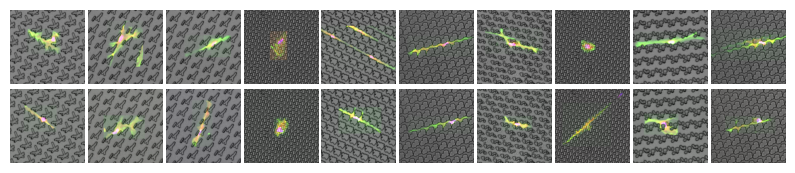

In [35]:
js = [0,1,3,2,6,7,8,9,10, 11] #np.random.choice(range(k), k_to_plot, replace=False)

fig, axs = plt.subplots(2, len(js), figsize=(len(js),2), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})


spath = 'qualitative_images/'
if not os.path.exists(spath):
    os.makedirs(spath)
    
for i, source in enumerate(['real', 'fake']):
    for j_temp in range(len(js)):
        a  = axs[i, j_temp]
        j = js[j_temp]
        if source == 'real':
            img_and_bg = imgs_real[j, :]
        else:
            img_and_bg = imgs_gen[j, :]
            # bg = imgs[j, 0]
        # plot superimposed cell on bg:
        im_to_plot =  plot_topo_cells(img_and_bg.cpu().permute(1, 2, 0).numpy(), bg_norm=0.6) / 255.
        a.imshow(im_to_plot)
        # a.imshow(img.permute(1, 2, 0).cpu().detach().numpy())
        a.axis('off')


plt.tight_layout(w_pad=1.08, h_pad=3.08)
plt.savefig(spath + 'qualitative_real_fake.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [19]:
# now zoom in on some images to show finer details

C:\Users\s161975\AppData\Local\Temp\ipykernel_5020\1356119199.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=1.08, h_pad=3.08)


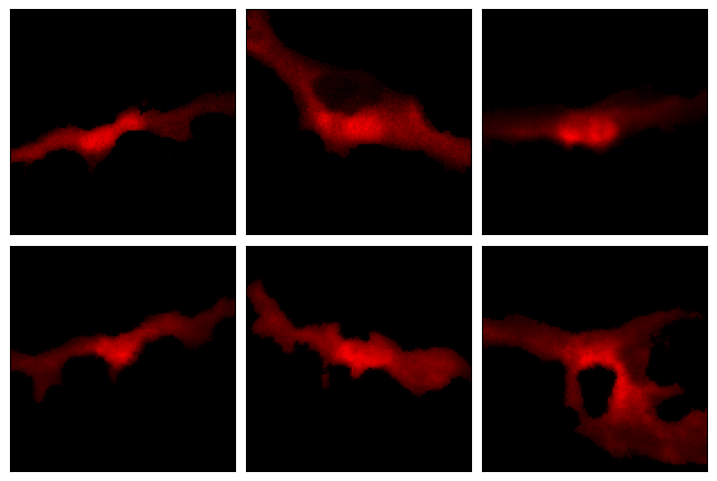

In [33]:
channel = -3
show_labs = False
pixels = 100

js = [7,8,10]

def find_center(img, channel=-1):
    # find the max intensity pixerl for the specified channel to determine the center
    i_flat = np.argmax(img[...,channel])
    i = np.unravel_index(i_flat, shape=img[...,channel].shape)
    return i

def zoom_image(img, center, pixels):
    assert len(img.shape) == 3
    low, high = center[0] - pixels//2, center[0] + pixels//2
    low = min(max(0, low), img.shape[0] - pixels)
    high = max(min(img.shape[0], high), pixels)
    left, right = center[1] - pixels//2, center[1] + pixels//2
    left = min(max(0, left), img.shape[0] - pixels)
    right = max(min(img.shape[0], right), pixels)
    img = img[low:high, left:right]
    return img, (low, high, left, right)

fig, axs = plt.subplots(2, len(js), figsize=(3*len(js),3*2), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})


spath = 'qualitative_images/'
if not os.path.exists(spath):
    os.makedirs(spath)
    
for i, source in enumerate(['real', 'fake']):
    for j_temp in range(len(js)):
        a  = axs[i, j_temp]
        j = js[j_temp]
        if source == 'real':
            img_and_bg = imgs_real[j, :]
        else:
            img_and_bg = imgs_gen[j, :]
            # bg = imgs[j, 0]
        # plot superimposed cell on bg:
        bg_norm = 0.0 if channel is not None else 0.5
        im_to_plot =  plot_topo_cells(img_and_bg.cpu().permute(1, 2, 0).numpy(), bg_norm=bg_norm) / 255.
        # zoom:
        center = find_center(im_to_plot, channel=-1)  # always base on dapi center so that loc stays consistent
        im_to_plot, _ = zoom_image(im_to_plot, center, pixels)
        mask = np.zeros_like(im_to_plot)
        if channel is not None:
            mask[..., channel] = 1
        else:
            mask = 1.
        a.imshow(im_to_plot * mask)
        # a.imshow(img.permute(1, 2, 0).cpu().detach().numpy())
        a.set_xticks([])
        a.set_yticks([])


labs = ('Real', 'Generated') if show_labs else ('\n', '\n')
axs[0,0].set_ylabel(labs[0], fontsize=16)
axs[1,0].set_ylabel(labs[1],fontsize=16)


plt.tight_layout(w_pad=1.08, h_pad=3.08)
plt.savefig(spath + f'qualitative_real_fake_zoom_chan{channel}.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [51]:
center

(117, 208)

In [18]:
# save some samples of generative process:


k = 16
bs = 2

trajs_gen = []
bgs_traj = []
for i in tqdm(range(np.ceil(k/bs).astype(int))):
    random_idx = np.random.randint(all_bgs.shape[0], size=bs)
    bg = all_bgs[random_idx].to(device)
    x1 = all_imgs[random_idx].to(device)
    bgs_traj.append(bg.cpu())
    some_bgs = utils.prepare_cfg_conditioning(bg, 0) if use_cfg else bg
    trajs_this_gen = generate_samples_topo(model, False, None, 0, 'test', some_bgs[:, None, ...],
                                           num_int_steps=100, use_cfg=True, cfg_strength=1, x1=x1,
                                           return_whole_traj=True)
    trajs_gen.append(trajs_this_gen.cpu().permute(1,0,2,3,4))


trajs_gen = torch.cat(trajs_gen, dim=0)
bgs_traj = torch.cat(bgs_traj, dim=0)


  0%|          | 0/8 [00:00<?, ?it/s]

Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.


  0%|          | 0/3 [00:00<?, ?it/s]

C:\Users\s161975\AppData\Local\Temp\ipykernel_7508\3654518370.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


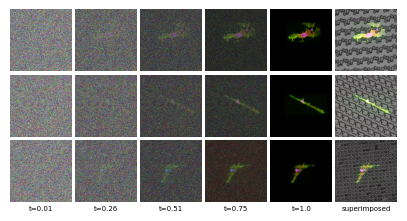

In [22]:
is_to_plot = [1, 2, 3]
num_times_to_plot = 5
steps_to_plot = np.round(np.linspace(0, trajs_gen.shape[1]-1, num_times_to_plot)).astype(int)

fig, ax = plt.subplots(len(is_to_plot), len(steps_to_plot)+1, figsize=((len(steps_to_plot)),2.5),
                       gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

for i1, i_to_plot in tqdm(enumerate(is_to_plot), total=len(is_to_plot)):
    for i2, t in enumerate(steps_to_plot):
        im_to_plot =  plot_topo_cells(trajs_gen[i_to_plot, t].permute(1,2,0).numpy(), bg_norm=0.4) / 255.
        ax[i1, i2].imshow(im_to_plot)
        ax[i1, i2].axis('off')

    ax[i1, -1].imshow(plot_topo_cells(
        torch.cat([
            bgs_traj[i_to_plot],
            trajs_gen[i_to_plot, -1]], dim=0
            ).cpu().permute(1,2,0).numpy(),
                bg_norm=0.6
        ) / 255.)
    ax[i1, -1].axis('off')

# add below the last line of subplots the corresponding timestamps (steps_to_plot+1) and for the final column the word 'superimposed':

for i2, t in enumerate(steps_to_plot):
    ax[-1, i2].text(0.5, -0.1, f't={float(np.round((t+1)/100,2))}', fontsize=5, ha='center', va='center', transform=ax[-1, i2].transAxes)
    ax[-1, i2].axis('off')

ax[-1, -1].text(0.5, -0.1, 'superimposed', fontsize=5, ha='center', va='center', transform=ax[-1, -1].transAxes)

plt.tight_layout()
plt.savefig(spath + 'qualitative_traj.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

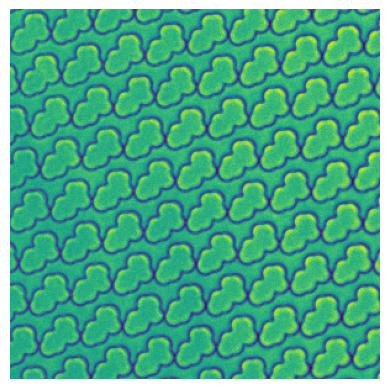

  0%|          | 0/6 [00:00<?, ?it/s]

Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.
Your vector field does not have `nn.Parameters` to optimize.


In [23]:
# classifier-free guidance diversity-fidelity trade-off:



k = 4
bg_id = 5
plt.imshow(all_bgs[bg_id].permute(1,2,0).cpu().numpy())
plt.axis('off')
plt.show()
cfg_strengths = [0, 0.1, 0.25, 0.5, 0.9, 1.]

imgs_gen_cfg = []
bgs = all_bgs[bg_id:bg_id+1].to(device).repeat(k, 1, 1, 1)
x1 = all_imgs[bg_id:bg_id+1].to(device).repeat(k, 1, 1, 1)

for cfg_strength in tqdm(cfg_strengths):
    bg = bgs
    some_bgs = utils.prepare_cfg_conditioning(bg, 0) if use_cfg else bg
    imgs_this_gen = generate_samples_topo(model, False, None, 0, 'test', some_bgs[:, None, ...], num_int_steps=100, use_cfg=True,
                                            cfg_strength=cfg_strength, x1=x1)
    imgs_gen_cfg.append(imgs_this_gen.cpu())



C:\Users\s161975\AppData\Local\Temp\ipykernel_7508\1713006878.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


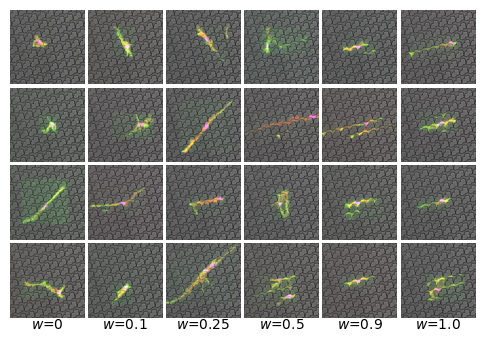

In [24]:
# make the plot:


fig, axs = plt.subplots(k, len(cfg_strengths),figsize=(len(cfg_strengths), k), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

for i in range(k):
    for j in range(len(cfg_strengths)):
        a = axs[i, j]
        img_and_bg = imgs_gen_cfg[j][i]
        im_to_plot = plot_topo_cells(img_and_bg.permute(1,2,0).numpy(), bg_norm=0.6) / 255.
        a.imshow(im_to_plot)
        a.axis('off')

# add cfg strength labels below the last row:

for j in range(len(cfg_strengths)):
    axs[-1, j].text(0.5, -0.1, f'$w$={cfg_strengths[j]}', fontsize=10, ha='center', va='center', transform=axs[-1, j].transAxes)
    axs[-1, j].axis('off')

plt.tight_layout()
plt.savefig(spath + f'qualitative_cfg_bg{bg_id}.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [101]:
imgs_gen_cfg[0].shape

torch.Size([4, 300, 300])

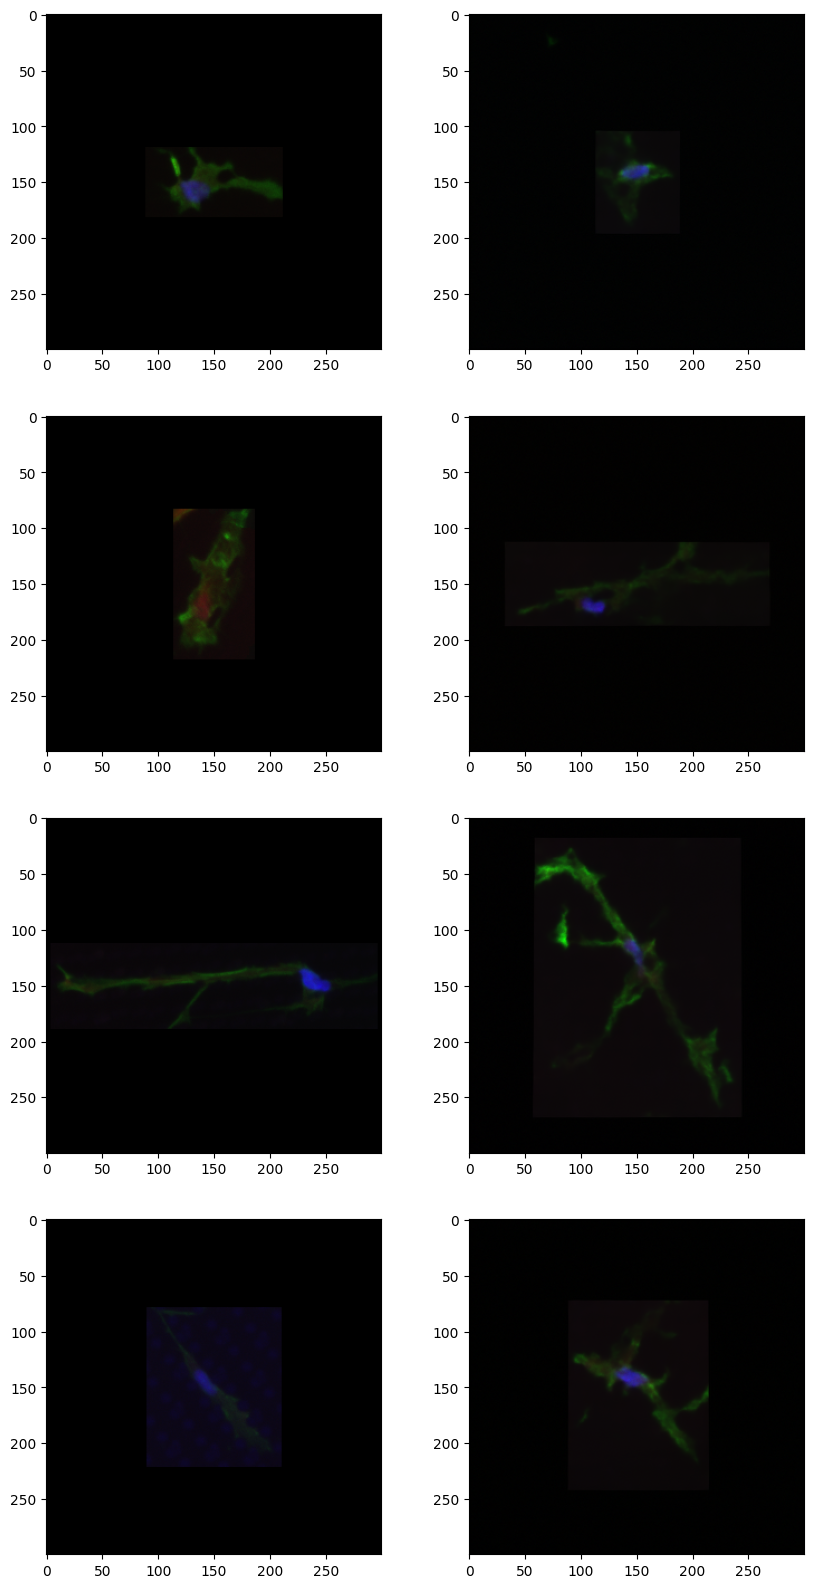

In [17]:
fig, axs = plt.subplots(bs, 2, figsize=(10,5*bs))
real_locs = []
for i in range(bs):
    u = np.random.uniform()
    if u < 0.5:
        real_idx=0
    else:
        real_idx=1
    axs[i, real_idx].imshow(all_imgs[i].permute(1,2,0).cpu().numpy())
    axs[i, 1-real_idx].imshow(imgs[i, 1:].permute(1,2,0).cpu().numpy())
    real_locs.append(real_idx)
plt.show()


In [7]:
bs=4
num_workers=0
downsampling_factor=1
limit_num_data=np.inf
crop_size=300
dataset = TopoDataSet(
    dir='data/',
    downsampling_factor=downsampling_factor,
    limit_num_data=limit_num_data,
    crop_size=crop_size,
    return_filename=True
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

dataset contains 5664 images


In [19]:
num_samples_to_make = 4
stain_names = ['background', 'YAP', 'Actin', 'DAPI']
spath = 'generated_images_tiff/'

for counter, (img, bg, filenames) in tqdm(enumerate(dataloader), total=int(np.ceil(num_samples_to_make / bs))):
    if counter * bs >= num_samples_to_make:
        break
    bg = bg[None, ...].to(device)  # add leading dim for the generation function
    bg_and_img = generate_samples_topo(model, False, None, 0, 'test', bg)
    for b in range(bg_and_img.shape[0]):
        filename = filenames[b]
        for c in range(bg_and_img.shape[1]):
            img_c = bg_and_img[b, c]  # shape (h,w)
            img_c = img_c.cpu().detach().numpy()
            img_c = (img_c * 255).astype(np.uint8)
            img_c = Image.fromarray(img_c)
            chip_folder = filename[filename.find('Chip'):filename.find('Chip')+11]
            obj_num = filename[filename.find('NucleiNr')+8:filename.find('NucleiNr')+12]
            fname_save = f'obj{obj_num}_stain{stain_names[c]}_fake.tiff'
            if not os.path.exists(os.path.join(spath, chip_folder +'_fake')):
                os.makedirs(os.path.join(spath, chip_folder +'_fake'))
            img_c.save(os.path.join(spath, chip_folder +'_fake', fname_save))


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
img_c.shape

torch.Size([300, 300])

In [32]:
# trajs = generate_samples_topo(model, False, None, 0, 'test', some_bgs, return_whole_traj=True)  # shape (100, bs, c, h, w)

In [41]:
# trajs = trajs / 2 + 0.5

MovieWriter imagemagick unavailable; using Pillow instead.


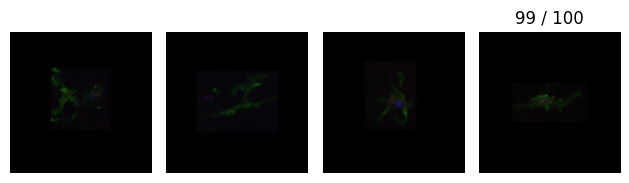

MovieWriter imagemagick unavailable; using Pillow instead.


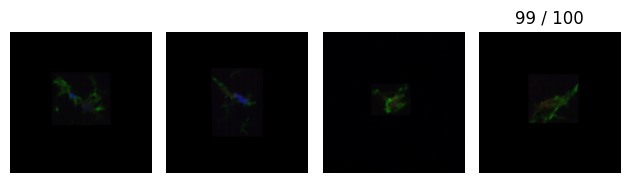

MovieWriter imagemagick unavailable; using Pillow instead.


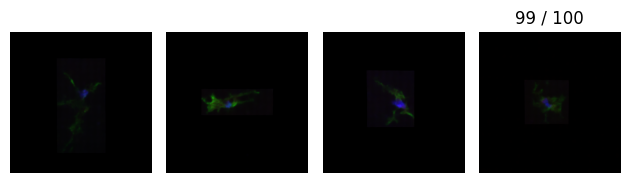

MovieWriter imagemagick unavailable; using Pillow instead.


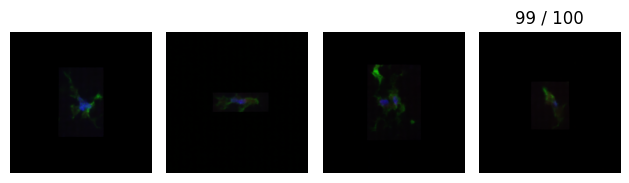

MovieWriter imagemagick unavailable; using Pillow instead.


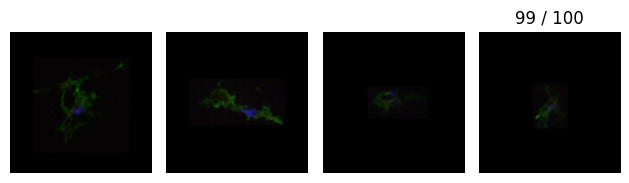

In [59]:
# make and save a gif animation of the trajectory using matplotlib funcanimation:
import matplotlib.animation as animation
from matplotlib import rc
import os



savedir = 'gifs/'
if not os.path.exists(savedir):
    os.makedirs(savedir)

num_reps = 5

for rep in range(num_reps):
    trajs = generate_samples_topo(model, False, None, 0, 'test', some_bgs, return_whole_traj=True)  # shape (100, bs, c, h, w)
    trajs = trajs / 2 + 0.5
    
    fig, ax = plt.subplots(ncols=4)
    fig.set_tight_layout(True)
    
    ims = []
    for j in range(4):
        im_j = ax[j].imshow(trajs[0, j].permute(1, 2, 0).cpu().detach().numpy())
        ax[j].axis('off')
        ims.append(im_j)
    
    
    def update(i):
        # set the title of the figure to the iteration number:
        plt.title(f'{i} / {trajs.shape[0]}')
        for j in range(4):
            ims[j].set_array(trajs[i, j].permute(1, 2, 0).cpu().detach().numpy())
        return ims
    
    ani = animation.FuncAnimation(fig, update, frames=100, blit=True)
    ani.save(savedir + f'traj_{rep}.gif', writer='imagemagick', fps=10)
    plt.show()


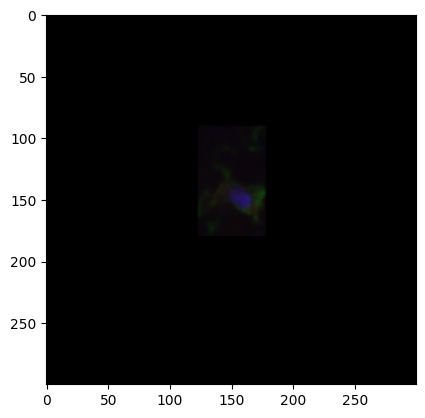

In [40]:
plt.imshow(trajs[-1,0].permute(1,2,0) / 2 + 0.5)
plt.show()

In [13]:
imgs.shape  # (bs, c, h, w)

torch.Size([4, 4, 300, 300])

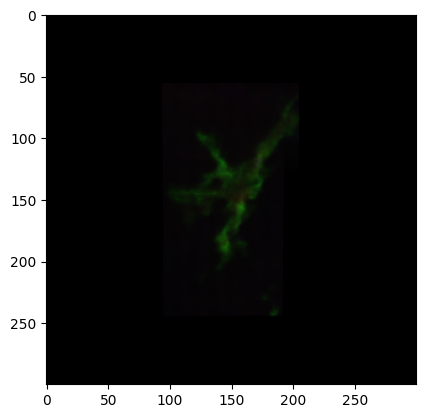

In [14]:
plt.figure()
plt.imshow(imgs[0, 1:].permute(1, 2, 0).cpu().detach().numpy())
plt.show()

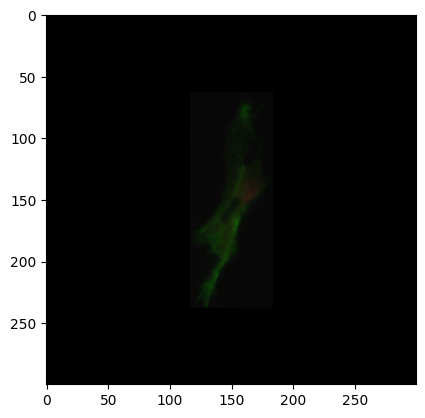

In [15]:
plt.figure()
plt.imshow(all_imgs[0].permute(1, 2, 0).cpu().detach().numpy())
plt.show()

In [16]:
all_imgs.max()

tensor(1.)

In [17]:
imgs[:,1:].min()

tensor(0., device='cuda:0')

In [18]:
# test = imgs[0, 1:].permute(1, 2, 0).cpu().detach().numpy()
# plt.hist(test.reshape(-1))
# plt.show()

In [24]:
# now do similarity search over the training set to find the k most similar images as the generated ones:

@torch.no_grad()
def similarity_search(generated_imgs, training_imgs, k=5, img_feat_extractor=lambda x: x, bs=32, use_cos_sim=False):
    # imgs: (bs, c, h, w)
    # all_imgs: (n, c, h, w)
    # k: int
    # returns: (bs, k, c, h, w)
    generated_imgs_preproc = []
    training_imgs_preproc = []
    print('starting preprocessing')
    for i in tqdm(range(0, generated_imgs.shape[0], bs)):
        generated_imgs_preproc.append(img_feat_extractor(generated_imgs[i:i+bs]).cpu())
    generated_imgs = torch.cat(generated_imgs_preproc, dim=0)
    for i in tqdm(range(0, training_imgs.shape[0], bs)):
        training_imgs_preproc.append(img_feat_extractor(training_imgs[i:i+bs]).cpu())
    training_imgs = torch.cat(training_imgs_preproc, dim=0)
    print(generated_imgs.shape)
    bs = generated_imgs.shape[0]
    n = training_imgs.shape[0]
    generated_imgs = generated_imgs.view(bs, -1)
    training_imgs = training_imgs.view(n, -1)
    if use_cos_sim:
        cos_sim = torch.nn.CosineSimilarity(dim=-1)
        sims = cos_sim(generated_imgs[:, None, :], training_imgs[None, :, :])
        dists = -sims
    else:
        dists = torch.cdist(generated_imgs, training_imgs)
    top_k = torch.topk(dists, k, dim=1, largest=False)
    return top_k.indices



In [25]:
k=3
top_k_idx = similarity_search(imgs[:, 1:].cpu(), all_imgs.cpu(), k=k, use_cos_sim=True)

starting preprocessing


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

torch.Size([4, 3, 300, 300])


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 24468480000 bytes.

In [21]:
# top_k_idx

NameError: name 'top_k_idx' is not defined

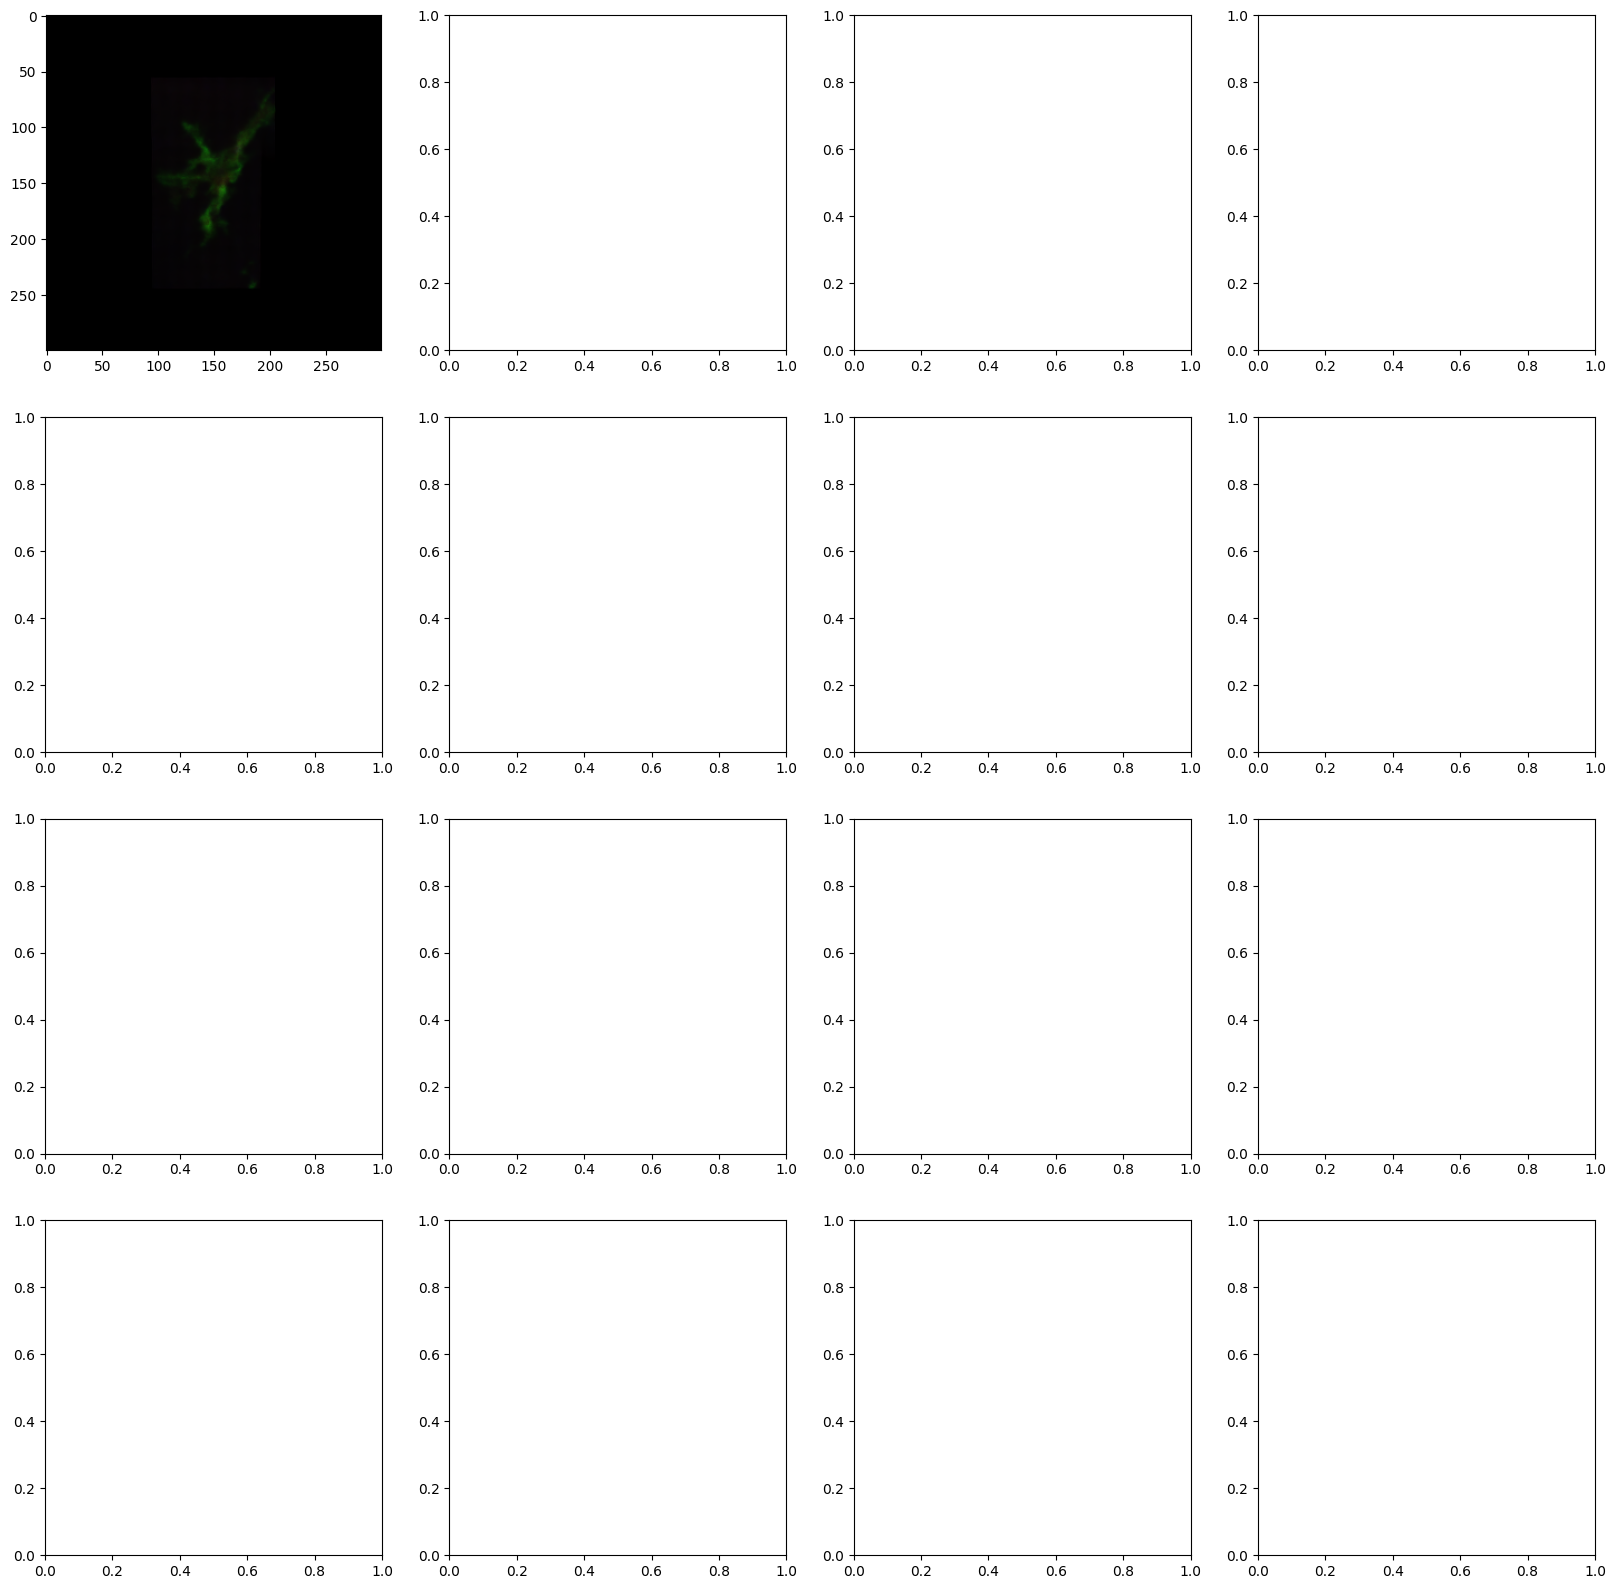

In [22]:
# plot the top_k most similar images:
fig, axs = plt.subplots(nrows=k+1, ncols=bs, figsize=(20,20))
for i in range(bs):
    axs[0, i].imshow(imgs[i, 1:].permute(1, 2, 0).cpu().detach().numpy()) # the first row is the generated images
    for j in range(k):
        axs[j+1, i].imshow(all_imgs[top_k_idx[i, j]].permute(1, 2, 0).cpu().detach().numpy())
        
plt.show()

In [49]:
# extract features using a pretrained model:
# device = 'cpu'
# first get the model":
import torchvision.models as models
model = models.resnet18(pretrained=True)
layer_feats = -8
feature_extractor = torch.nn.Sequential(*list(model.children())[:layer_feats]).to(device)

In [50]:
torch.cuda.empty_cache()

In [ ]:
top_k_idx_feat_extr = similarity_search(imgs[:, 1:].to(device), all_imgs.to(device), k=k,
                                        img_feat_extractor=lambda x: feature_extractor(x), bs=16, use_cos_sim=True)


starting preprocessing


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/354 [00:00<?, ?it/s]

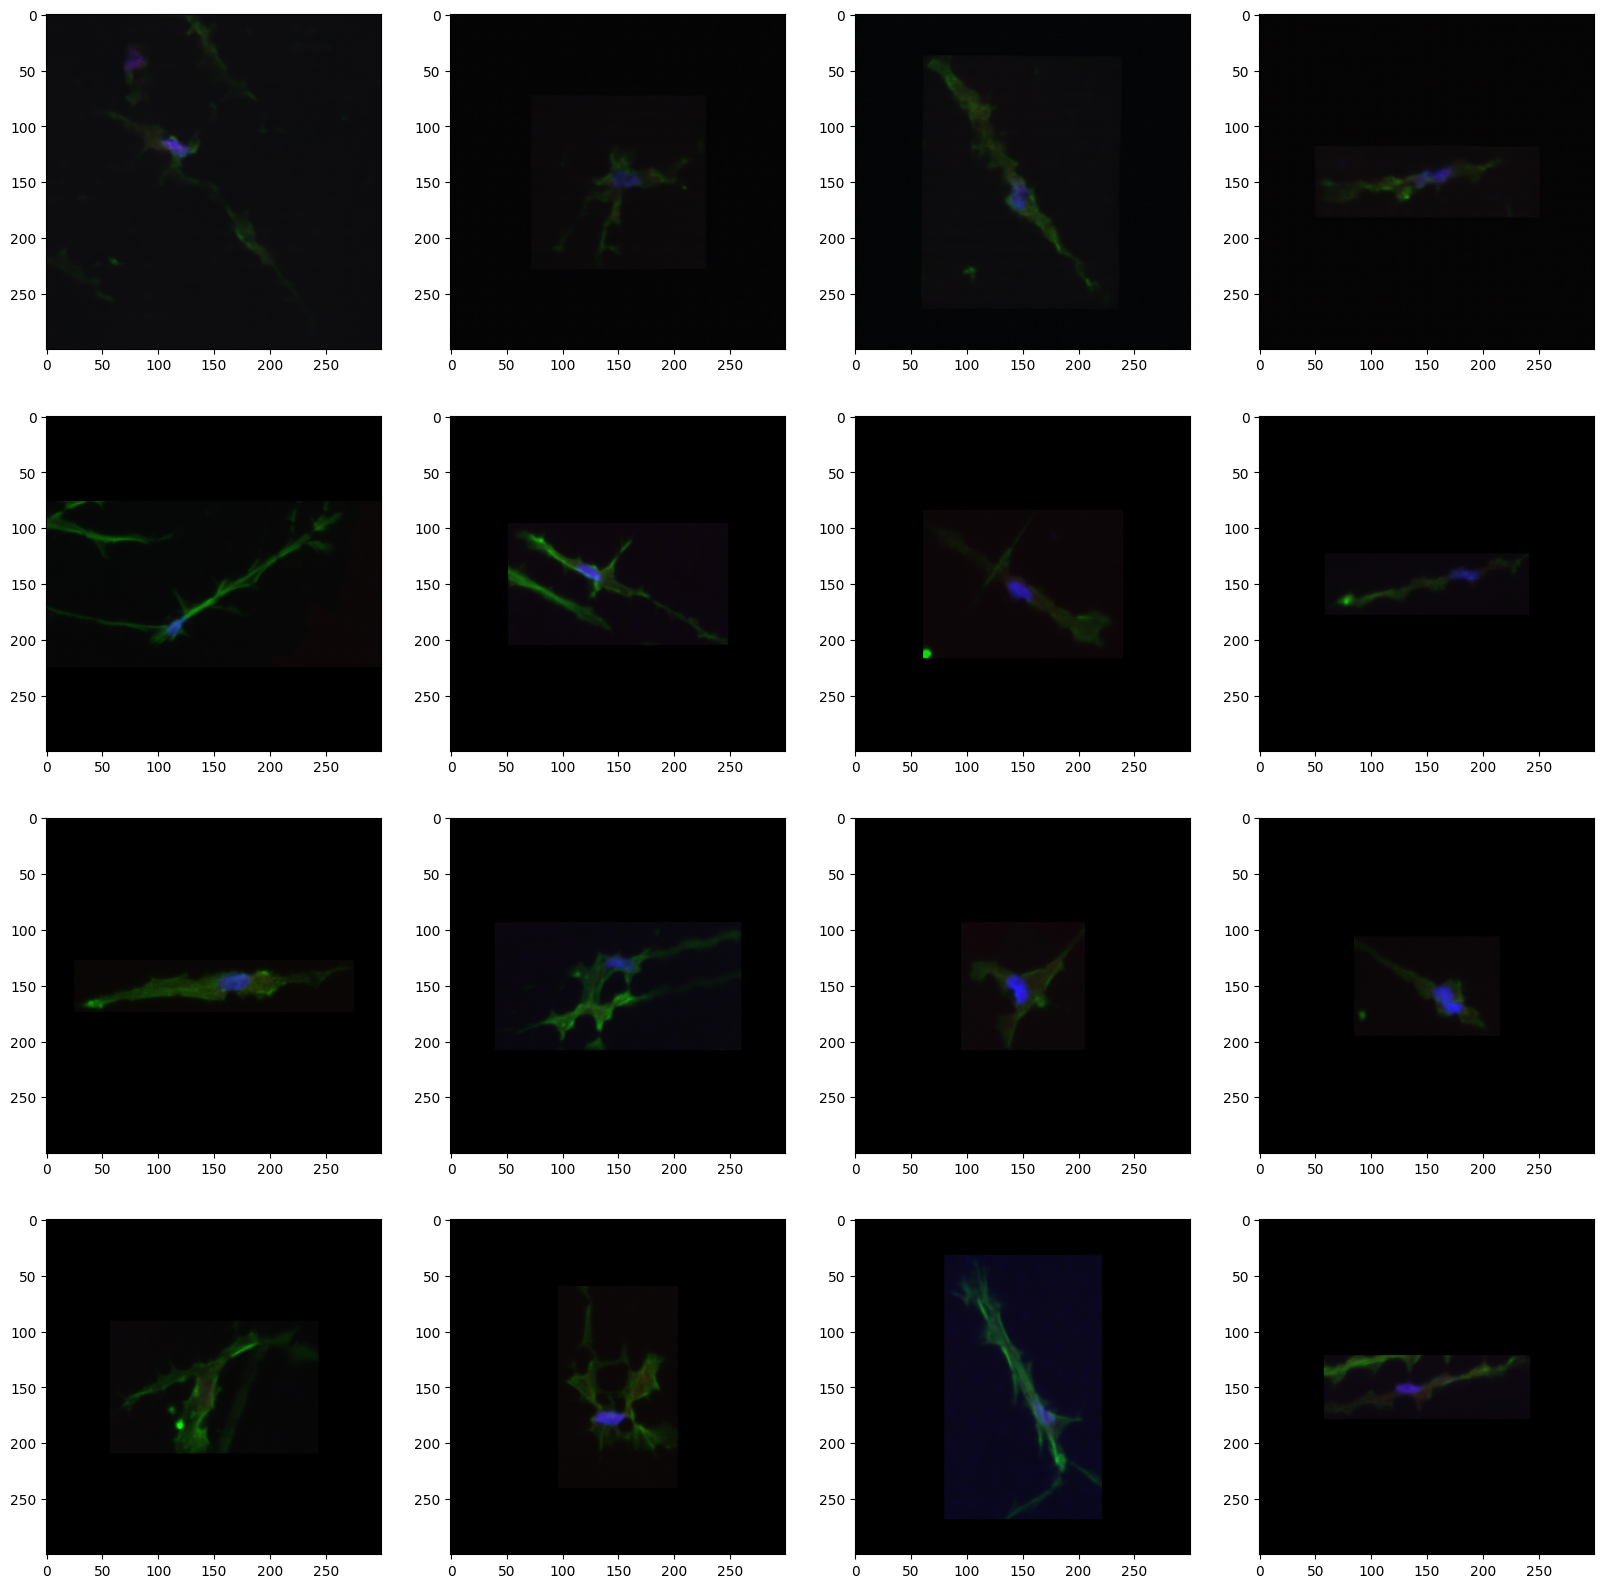

In [28]:
# plot the top_k most similar images:
fig, axs = plt.subplots(nrows=k+1, ncols=bs, figsize=(20,20))
for i in range(bs):
    axs[0, i].imshow(imgs[i, 1:].permute(1, 2, 0).cpu().detach().numpy()) # the first row is the generated images
    for j in range(k):
        axs[j+1, i].imshow(all_imgs[top_k_idx_feat_extr[i, j]].permute(1, 2, 0).cpu().detach().numpy())

plt.show()

In [ ]:
# randomly plot some generated images and images from the training set:

In [51]:
bs = 8
random_idx = np.random.choice(all_imgs.shape[0], bs)
some_bgs = all_bgs[random_idx][None, ...].to(device)
imgs_compare = generate_samples_topo(model, False, None, 0, 'test', some_bgs)

In [52]:
imgs_real = all_imgs[random_idx]

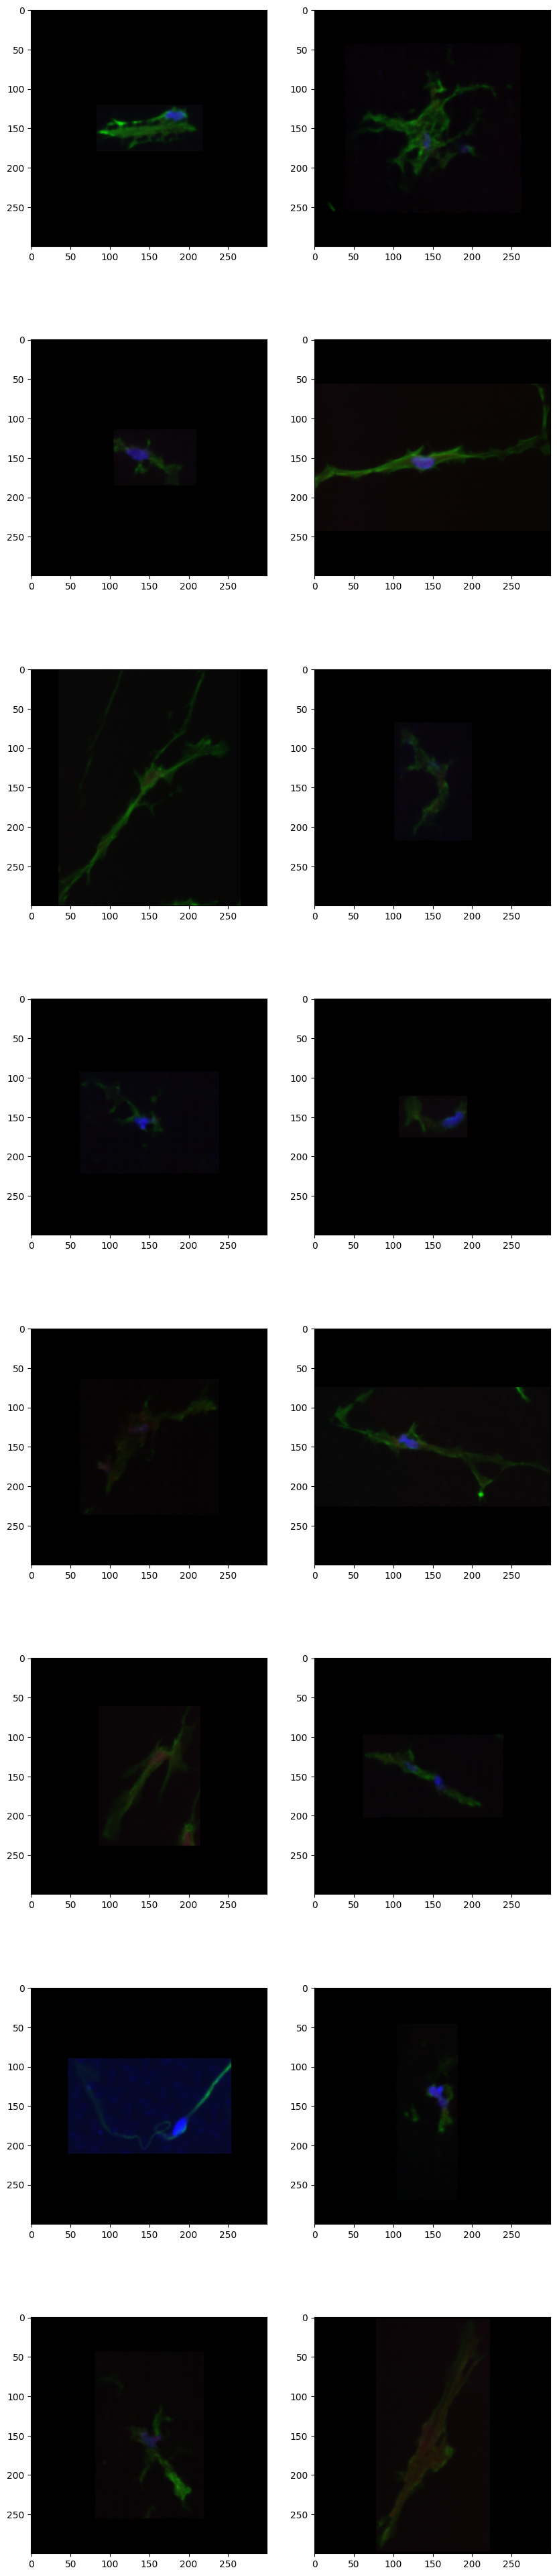

In [18]:
for l in real_locs:
    print(l)

0
0
0
0


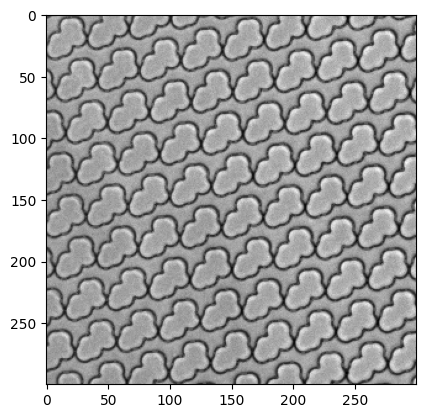

In [57]:
plt.figure()
plt.imshow(all_bgs[0].permute(1, 2, 0).cpu().detach().numpy(), cmap='grey')
plt.show()